# Reflectance Exercise 3 — finding an operational saturation region

Compare repeated distributions across ordered surface conditions and identify where neighbouring responses become difficult to distinguish.

Start with the supplied synthetic example so that every cell runs before you have collected data. The example demonstrates the analysis route; it is not evidence about your robot and its values are not coursework answers. You do not need to understand or edit the example-generation cell.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
rng = np.random.default_rng(2026)


## 1. Use the example or your own data

Leave `USE_EXAMPLE_DATA` set to `True` for your first run. To use your measurements, upload the CSV, change it to `False`, and enter its filename. This is the main data-loading setting you need to edit.

Expected raw CSV columns: `test_name`, `surface_value`, `trial_num`, `sample_num`, `sample_time`, `sensor_num`, and `sensor_reading`.

`surface_value` uses the printed 8-bit convention: 255 is white and 0 is black.


In [2]:
USE_EXAMPLE_DATA = True
CSV_FILENAME = "reflectance_exercise03.csv"

print("Using:", "synthetic example" if USE_EXAMPLE_DATA else CSV_FILENAME)


Using: synthetic example


## 2. Create the small synthetic example

The example contains an obvious dark-region plateau in two measurement orders. It is illustrative rather than an expected result.


In [3]:
rows = []
surface_values = [220, 160, 100, 60, 20, 0]
for trial_num, order in [(1, surface_values), (2, surface_values[::-1])]:
    for condition_num, surface_value in enumerate(order):
        darkness = min((255 - surface_value) / 255, 0.76)
        for sample_num in range(1, 21):
            sample_time = trial_num * 1_000_000 + (condition_num * 20 + sample_num) * 10_000
            for sensor_num in range(5):
                typical = 230 + (1500 + 35 * sensor_num) * (1 - np.exp(-4 * darkness))
                rows.append({
                    "test_name": "saturationTest", "surface_value": surface_value,
                    "trial_num": trial_num, "sample_num": sample_num,
                    "sample_time": sample_time, "sensor_num": sensor_num,
                    "sensor_reading": typical + rng.normal(0, 7),
                })
example_data = pd.DataFrame(rows)


## 3. Load and preview the selected data

This is where an uploaded CSV enters the notebook. Check that the column names, units and labels match the exercise before continuing.


In [4]:
if USE_EXAMPLE_DATA:
    data = example_data.copy()
else:
    data = pd.read_csv(CSV_FILENAME)

data.head()


,test_name,surface_value,trial_num,sample_num,sample_time,sensor_num,sensor_reading
0,saturationTest,220,1,1,1010000,0,858.174555
1,saturationTest,220,1,1,1010000,1,880.197361
2,saturationTest,220,1,1,1010000,2,880.026028
3,saturationTest,220,1,1,1010000,3,917.857664
4,saturationTest,220,1,1,1010000,4,927.342274


## 4. Select the saturation test rows


In [5]:
TEST_NAME = "saturationTest"
SELECTED_SENSOR = 0
saturation_data = data.loc[data["test_name"] == TEST_NAME].copy()
saturation_data.head()


,test_name,surface_value,trial_num,sample_num,sample_time,sensor_num,sensor_reading
0,saturationTest,220,1,1,1010000,0,858.174555
1,saturationTest,220,1,1,1010000,1,880.197361
2,saturationTest,220,1,1,1010000,2,880.026028
3,saturationTest,220,1,1,1010000,3,917.857664
4,saturationTest,220,1,1,1010000,4,927.342274


## 5. Plot complete reading distributions

The panels retain every reading. Look for a response change over lighter conditions followed by overlapping boxes over darker conditions.


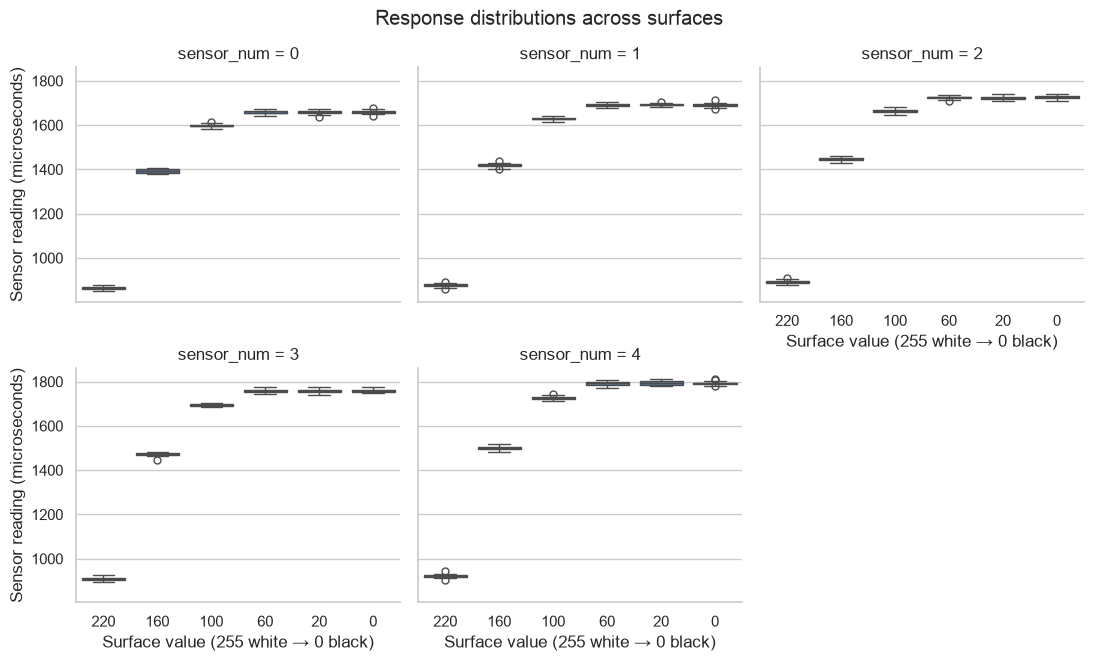

In [6]:
surface_order = sorted(saturation_data["surface_value"].unique(), reverse=True)
g = sns.catplot(
    data=saturation_data, x="surface_value", y="sensor_reading",
    col="sensor_num", col_wrap=3, kind="box", order=surface_order,
    height=3.2, aspect=1.15,
)
g.set_axis_labels("Surface value (255 white → 0 black)", "Sensor reading (microseconds)")
g.figure.suptitle("Response distributions across surfaces", y=1.03)
plt.show()


## 6. Check whether both trials show the same pattern

This plot keeps the two measurement passes separate for one selected sensor. Change `SELECTED_SENSOR` above to inspect all five.


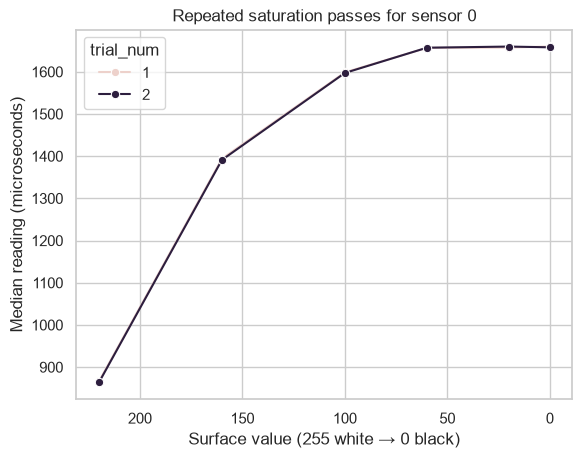

In [7]:
trial_summary = (
    saturation_data.groupby(["sensor_num", "trial_num", "surface_value"], as_index=False)
    .agg(typical_us=("sensor_reading", "median"))
)
selected_trials = trial_summary.loc[trial_summary["sensor_num"] == SELECTED_SENSOR]
sns.lineplot(data=selected_trials, x="surface_value", y="typical_us", hue="trial_num", marker="o")
plt.gca().invert_xaxis()
plt.title(f"Repeated saturation passes for sensor {SELECTED_SENSOR}")
plt.xlabel("Surface value (255 white → 0 black)")
plt.ylabel("Median reading (microseconds)")
plt.show()


## 7. Compare neighbouring conditions

`groupby` calculates a median and standard deviation for each sensor and surface. The `not_separated` flag is a screening rule, not proof of physical saturation.


In [8]:
response_summary = (
    saturation_data.groupby(["sensor_num", "surface_value"], as_index=False)
    .agg(samples=("sensor_reading", "size"),
         typical_us=("sensor_reading", "median"),
         sd_us=("sensor_reading", "std"))
    .sort_values(["sensor_num", "surface_value"], ascending=[True, False])
)
response_summary["change_to_next_us"] = (
    response_summary.groupby("sensor_num")["typical_us"].diff().abs()
)
response_summary["local_sd_us"] = (
    response_summary.groupby("sensor_num")["sd_us"]
    .rolling(2).mean().reset_index(level=0, drop=True)
)
response_summary["not_separated"] = (
    response_summary["change_to_next_us"] <= response_summary["local_sd_us"]
)
response_summary


,sensor_num,surface_value,samples,typical_us,sd_us,change_to_next_us,local_sd_us,not_separated
5,0,220,40,864.368853,6.649314,NaN,NaN,False
4,0,160,40,1392.470995,7.979944,528.102142,7.314629,False
3,0,100,40,1597.522774,6.837168,205.051779,7.408556,False
2,0,60,40,1656.779193,7.676078,59.256419,7.256623,False
1,0,20,40,1659.104851,7.740382,2.325658,7.708230,True
0,0,0,40,1659.643306,6.941497,0.538454,7.340940,True
11,1,220,40,876.405024,6.255184,NaN,NaN,False
10,1,160,40,1420.097546,7.335481,543.692523,6.795332,False
9,1,100,40,1628.374647,6.743038,208.277101,7.039260,False
8,1,60,40,1690.292601,6.488152,61.917954,6.615595,False


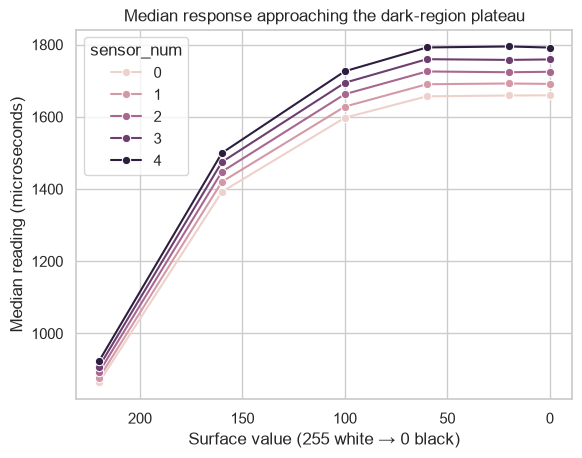

In [9]:
sns.lineplot(
    data=response_summary,
    x="surface_value",
    y="typical_us",
    hue="sensor_num",
    marker="o",
)
plt.gca().invert_xaxis()
plt.title("Median response approaching the dark-region plateau")
plt.xlabel("Surface value (255 white → 0 black)")
plt.ylabel("Median reading (microseconds)")
plt.show()


## What to notice

- Does a candidate plateau appear in both measurement passes?
- Do all five sensors reach it over the same tested interval?
- Could surface contrast, placement or lighting explain the flat response?
- Report a tested interval rather than inventing an exact threshold.
